In [ ]:
# Only run this cell if the required packages are not installed
!pip install pandas matplotlib scikit-learn numpy

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 36.0 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 40.3 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 KB 2.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 3.6 MB/s eta 0:00:0000:01


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [58]:
quantization_dir = {
    "float32": "/sdf/home/s/sagar/forPrajita/QiML/ModelResponse/float32/",  
    "24-bit": "/sdf/home/s/sagar/forPrajita/QiML/ModelResponse/24bit/",
    "20-bit": "/sdf/home/s/sagar/forPrajita/QiML/ModelResponse/20bit/",
    "18-bit": "/sdf/home/s/sagar/forPrajita/QiML/ModelResponse/18bit/",
}


In [ ]:
quantization_files = {
    "float32": ["bkg_1M.dat", "Ato4l.dat", "hToTauNu.dat", "hToTauTau.dat", "LQ.dat" ],
    "24-bit": ["bkg_100k.dat" ],
    "20-bit": ["bkg_100k.dat", "hToTauNu_50k.dat", "hToTauTau_50k.dat" ],
    "18-bit": ["bkg_100k.dat", "Ato4l_50k.dat", "hToTauNu_50k.dat", "hToTauTau_50k.dat", "LQ_50k.dat" ],
}

In [6]:
quantization_colors = {
    "float32": "#ff7f0e",   # orange
    "24-bit": "#2ca02c", # green
    "20-bit": "#d62728", # red
    "18-bit":"#1f77b4", # blue
}

In [7]:
def extract_signal_name(filename):
    return filename.replace(".dat", "").split("_")[0]

In [ ]:
# Where to save the comparison plots
output_plot_dir = "../output/QuantizationComparison/"
os.makedirs(output_plot_dir, exist_ok=True)

In [11]:
def load_norm_data(file_path):
    """Load normalization data from a whitespace-delimited file."""
    return pd.read_csv(file_path, sep='\s+', comment="#", header=None)

In [60]:
norms = {}

for bit, files in quantization_files.items():
    bit_dir = quantization_dir[bit]
    norms[bit] = {}

    for fname in files:
        signal = extract_signal_name(fname)
        file_path = os.path.join(bit_dir, fname)

        df = load_norm_data(file_path)

        if signal not in norms[bit]:
            norms[bit][signal] = []

        norms[bit][signal].append(df)


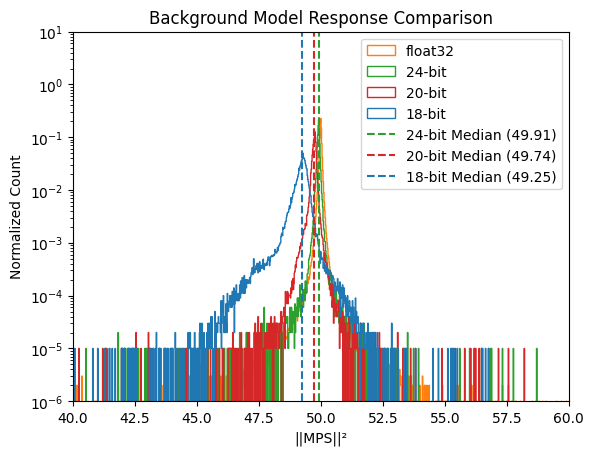

In [63]:
xmin = 40
xmax = 60
bins = np.linspace(xmin, xmax, 1000)
norm_bkg_float32 = norms["float32"]["bkg"][0]
norm_bkg_24bit = norms["24-bit"]["bkg"][0][0]
norm_bkg_20bit = norms["20-bit"]["bkg"][0][0]
norm_bkg_18bit = norms["18-bit"]["bkg"][0][0]
median_24bit = np.median(norm_bkg_24bit)
median_20bit = np.median(norm_bkg_20bit)
median_18bit = np.median(norm_bkg_18bit)
plt.hist(norm_bkg_float32, weights=np.array([1.]*len(norm_bkg_float32))/len(norm_bkg_float32), bins=bins, histtype='step', color=quantization_colors["float32"], label="float32")
plt.hist(norm_bkg_24bit, weights=np.array([1.]*len(norm_bkg_24bit))/len(norm_bkg_24bit), bins=bins, histtype='step', color=quantization_colors["24-bit"], label="24-bit")
plt.hist(norm_bkg_20bit, weights=np.array([1.]*len(norm_bkg_20bit))/len(norm_bkg_20bit), bins=bins, histtype='step', color=quantization_colors["20-bit"], label="20-bit")
plt.hist(norm_bkg_18bit, weights=np.array([1.]*len(norm_bkg_18bit))/len(norm_bkg_18bit), bins=bins, histtype='step', color=quantization_colors["18-bit"], label="18-bit")
# plt.hist(norm_bkg_18bit+ (50-median_18bit), bins=bins, histtype='step', color=quantization_colors["18-bit"], label="18-bit shifted", linestyle='--')
plt.axvline(median_24bit, color=quantization_colors["24-bit"], linestyle='--', label="24-bit Median ({})".format(round(median_24bit,2)))
plt.axvline(median_20bit, color=quantization_colors["20-bit"], linestyle='--', label="20-bit Median ({})".format(round(median_20bit,2)))
plt.axvline(median_18bit, color=quantization_colors["18-bit"], linestyle='--', label="18-bit Median ({})".format(round(median_18bit,2)))
plt.xlabel("||MPS||\u00b2")
plt.yscale("log")
plt.ylim(1e-6, 10)
plt.xlim(xmin, xmax)
plt.ylabel("Normalized Count")
plt.title("Background Model Response Comparison")
plt.legend()

In [31]:
xmin = 0
xmax = 100
bins = np.linspace(xmin, xmax, 1000)

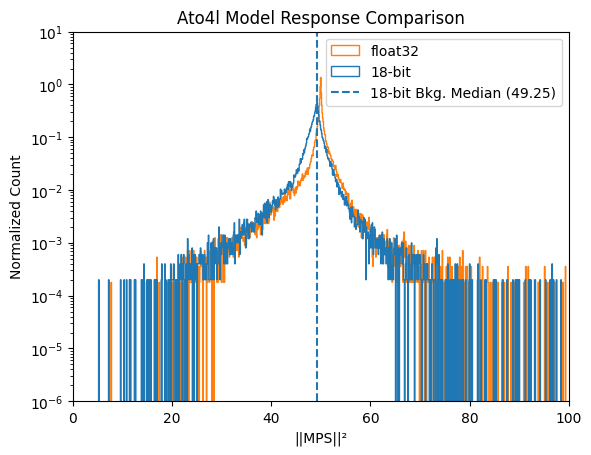

In [33]:
norm_Ato4l_float32 = norms["float32"]["Ato4l"][0]
norm_Ato4l_18bit = norms["18-bit"]["Ato4l"][0][0]

plt.hist(norm_Ato4l_float32, weights=np.array([1.]*len(norm_Ato4l_float32))/len(norm_Ato4l_float32), bins=bins, density=True, histtype='step', color=quantization_colors["float32"], label="float32")
plt.hist(norm_Ato4l_18bit, weights=np.array([1.]*len(norm_Ato4l_18bit))/len(norm_Ato4l_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit")
# plt.hist(norm_Ato4l_18bit+ (50-median_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit shifted", linestyle='--')
plt.axvline(median_18bit, color=quantization_colors["18-bit"], linestyle='--', label="18-bit Bkg. Median ({})".format(round(median_18bit,2)))
plt.xlabel("||MPS||\u00b2")
plt.yscale("log")
plt.ylim(1e-6, 10)
plt.xlim(xmin, xmax)
plt.ylabel("Normalized Count")
plt.title("Ato4l Model Response Comparison")
plt.legend()


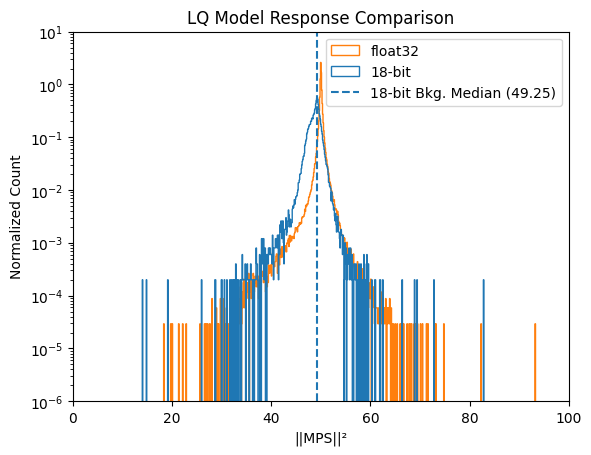

In [34]:
norm_LQ_float32 = norms["float32"]["LQ"][0]
norm_LQ_18bit = norms["18-bit"]["LQ"][0][0]

plt.hist(norm_LQ_float32, weights=np.array([1.]*len(norm_LQ_float32))/len(norm_LQ_float32), bins=bins, density=True, histtype='step', color=quantization_colors["float32"], label="float32")
plt.hist(norm_LQ_18bit, weights=np.array([1.]*len(norm_LQ_18bit))/len(norm_LQ_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit")
# plt.hist(norm_LQ_18bit+ (50-median_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit shifted", linestyle='--')
plt.axvline(median_18bit, color=quantization_colors["18-bit"], linestyle='--', label="18-bit Bkg. Median ({})".format(round(median_18bit,2)))
plt.xlabel("||MPS||\u00b2")
plt.yscale("log")
plt.ylim(1e-6, 10)
plt.xlim(xmin, xmax)
plt.ylabel("Normalized Count")
plt.title("LQ Model Response Comparison")
plt.legend()


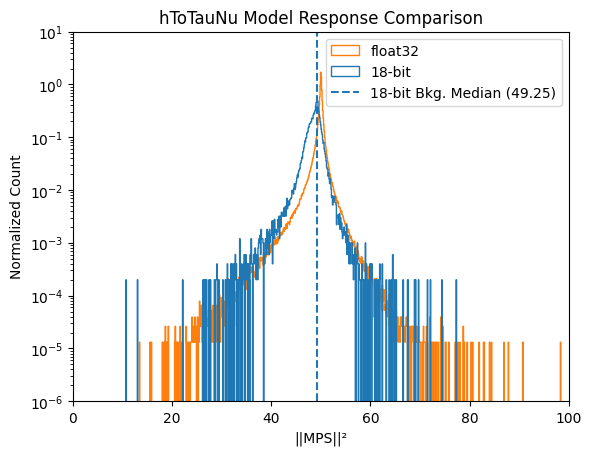

In [36]:
norm_hToTauNu_float32 = norms["float32"]["hToTauNu"][0]
norm_hToTauNu_18bit = norms["18-bit"]["hToTauNu"][0][0]

plt.hist(norm_hToTauNu_float32, weights=np.array([1.]*len(norm_hToTauNu_float32))/len(norm_hToTauNu_float32), bins=bins, density=True, histtype='step', color=quantization_colors["float32"], label="float32")
plt.hist(norm_hToTauNu_18bit, weights=np.array([1.]*len(norm_hToTauNu_18bit))/len(norm_hToTauNu_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit")
# plt.hist(norm_hToTauNu_18bit+ (50-median_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit shifted", linestyle='--')
plt.axvline(median_18bit, color=quantization_colors["18-bit"], linestyle='--', label="18-bit Bkg. Median ({})".format(round(median_18bit,2)))
plt.xlabel("||MPS||\u00b2")
plt.yscale("log")
plt.ylim(1e-6, 10)
plt.xlim(xmin, xmax)
plt.ylabel("Normalized Count")
plt.title("hToTauNu Model Response Comparison")
plt.legend()


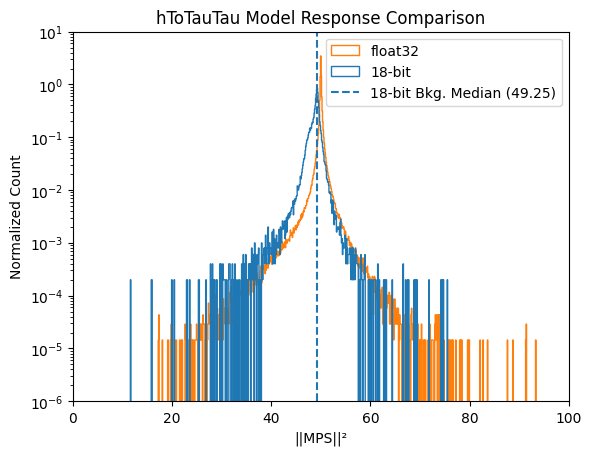

In [37]:
norm_hToTauTau_float32 = norms["float32"]["hToTauTau"][0]
norm_hToTauTau_18bit = norms["18-bit"]["hToTauTau"][0][0]

plt.hist(norm_hToTauTau_float32, weights=np.array([1.]*len(norm_hToTauTau_float32))/len(norm_hToTauTau_float32), bins=bins, density=True, histtype='step', color=quantization_colors["float32"], label="float32")
plt.hist(norm_hToTauTau_18bit, weights=np.array([1.]*len(norm_hToTauTau_18bit))/len(norm_hToTauTau_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit")
# plt.hist(norm_hToTauTau_18bit+ (50-median_18bit), bins=bins, density=True, histtype='step', color=quantization_colors["18-bit"], label="18-bit shifted", linestyle='--')
plt.axvline(median_18bit, color=quantization_colors["18-bit"], linestyle='--', label="18-bit Bkg. Median ({})".format(round(median_18bit,2)))
plt.xlabel("||MPS||\u00b2")
plt.yscale("log")
plt.ylim(1e-6, 10)
plt.xlim(xmin, xmax)
plt.ylabel("Normalized Count")
plt.title("hToTauTau Model Response Comparison")
plt.legend()


In [38]:
def get_anomaly_scores(norm, target):
    return np.abs(norm - target)

In [39]:
#copying same roc def as tn4ml eval 
def get_roc_curve_data(y_true: np.ndarray, y_scores: np.ndarray, anomaly_det: bool = False):
    if anomaly_det:
        true_val = np.concatenate((np.ones(y_scores.shape[0]), np.zeros(y_true.shape[0])))
        pred_val = np.concatenate((y_scores, y_true))
    else:
        true_val = y_true
        pred_val = y_scores
    
    fpr, tpr, _ = roc_curve(true_val, pred_val, drop_intermediate=False)

    return fpr, tpr

In [45]:
# this is ROC with shifted peak for 18 bit
bkg_score_float32 = get_anomaly_scores(norm_bkg_float32[:100000], 50)
Ato4l_score_float32 = get_anomaly_scores(norm_Ato4l_float32[:50000], 50)
LQ_score_float32 = get_anomaly_scores(norm_LQ_float32[:50000], 50)
hToTauNu_score_float32 = get_anomaly_scores(norm_hToTauNu_float32[:50000], 50)
hToTauTau_score_float32 = get_anomaly_scores(norm_hToTauTau_float32[:50000], 50)

bkg_score_18bit = get_anomaly_scores(norm_bkg_18bit, median_18bit)
Ato4l_score_18bit = get_anomaly_scores(norm_Ato4l_18bit, median_18bit)
LQ_score_18bit = get_anomaly_scores(norm_LQ_18bit, median_18bit)
hToTauNu_score_18bit = get_anomaly_scores(norm_hToTauNu_18bit, median_18bit)
hToTauTau_score_18bit = get_anomaly_scores(norm_hToTauTau_18bit, median_18bit)

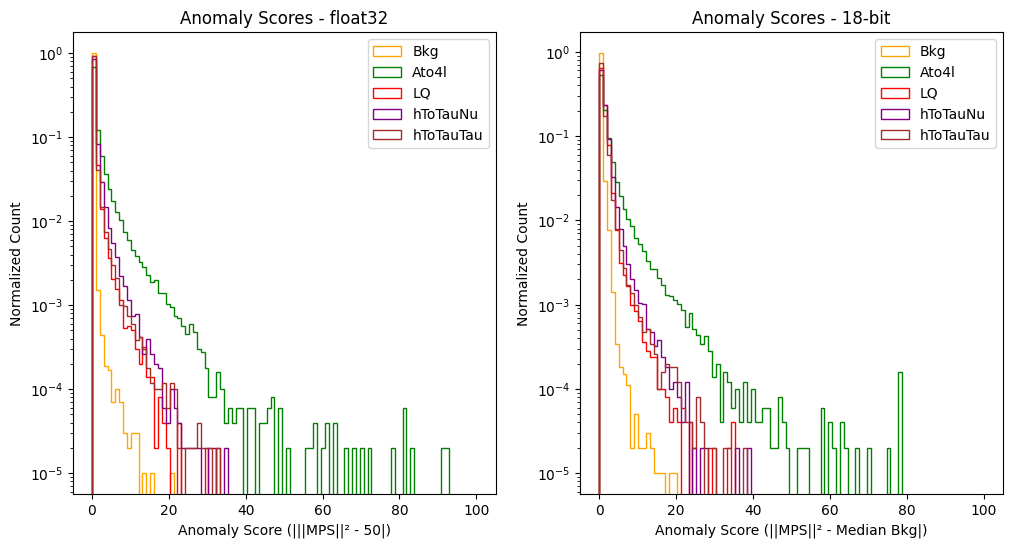

In [49]:
# Plot the anomaly scores (not ROC) in two separate panels for float32 and 18-bit
plt.figure(figsize=(12, 6))
# Float32 scores
bins = np.linspace(0, 100, 100)
plt.subplot(1, 2, 1)
plt.hist(bkg_score_float32, weights=np.array([1.]*len(bkg_score_float32))/len(bkg_score_float32), bins=bins, histtype='step', color='orange', label="Bkg")
plt.hist(Ato4l_score_float32, weights=np.array([1.]*len(Ato4l_score_float32))/len(Ato4l_score_float32), bins=bins, histtype='step', color='green', label="Ato4l")
plt.hist(LQ_score_float32, weights=np.array([1.]*len(LQ_score_float32))/len(LQ_score_float32), bins=bins, histtype='step', color='red', label="LQ")
plt.hist(hToTauNu_score_float32, weights=np.array([1.]*len(hToTauNu_score_float32))/len(hToTauNu_score_float32), bins=bins, histtype='step', color='purple', label="hToTauNu")
plt.hist(hToTauTau_score_float32, weights=np.array([1.]*len(hToTauTau_score_float32))/len(hToTauTau_score_float32), bins=bins, histtype='step', color='brown', label="hToTauTau")
plt.xlabel("Anomaly Score (|||MPS||\u00b2 - 50|)")
plt.yscale("log")
plt.ylabel("Normalized Count")
plt.title("Anomaly Scores - float32")
plt.legend()
# 18-bit scores
plt.subplot(1, 2, 2)
plt.hist(bkg_score_18bit, weights=np.array([1.]*len(bkg_score_18bit))/len(bkg_score_18bit), bins=bins, histtype='step', color='orange', label="Bkg")
plt.hist(Ato4l_score_18bit, weights=np.array([1.]*len(Ato4l_score_18bit))/len(Ato4l_score_18bit), bins=bins, histtype='step', color='green', label="Ato4l")
plt.hist(LQ_score_18bit, weights=np.array([1.]*len(LQ_score_18bit))/len(LQ_score_18bit), bins=bins, histtype='step', color='red', label="LQ")
plt.hist(hToTauNu_score_18bit, weights=np.array([1.]*len(hToTauNu_score_float32))/len(hToTauNu_score_float32), bins=bins, histtype='step', color='purple', label="hToTauNu")
plt.hist(hToTauTau_score_18bit, weights=np.array([1.]*len(hToTauTau_score_18bit))/len(hToTauTau_score_18bit), bins=bins, histtype='step', color='brown', label="hToTauTau")
plt.xlabel("Anomaly Score (||MPS||\u00b2 - Median Bkg|)")
plt.yscale("log")
plt.ylabel("Normalized Count")
plt.title("Anomaly Scores - 18-bit")
plt.legend()

In [51]:
fpr_Ato4l_float32, tpr_Ato4l_float32 = get_roc_curve_data(bkg_score_float32, Ato4l_score_float32, anomaly_det=True)
fpr_LQ_float32, tpr_LQ_float32 = get_roc_curve_data(bkg_score_float32, LQ_score_float32, anomaly_det=True)
fpr_hToTauNu_float32, tpr_hToTauNu_float32 = get_roc_curve_data(bkg_score_float32, hToTauNu_score_float32, anomaly_det=True)
fpr_hToTauTau_float32, tpr_hToTauTau_float32 = get_roc_curve_data(bkg_score_float32, hToTauTau_score_float32, anomaly_det=True)

fpr_Ato4l_18bit, tpr_Ato4l_18bit = get_roc_curve_data(bkg_score_18bit, Ato4l_score_18bit, anomaly_det=True)
fpr_LQ_18bit, tpr_LQ_18bit = get_roc_curve_data(bkg_score_18bit, LQ_score_18bit, anomaly_det=True)
fpr_hToTauNu_18bit, tpr_hToTauNu_18bit = get_roc_curve_data(bkg_score_18bit, hToTauNu_score_18bit, anomaly_det=True)
fpr_hToTauTau_18bit, tpr_hToTauTau_18bit = get_roc_curve_data(bkg_score_18bit, hToTauTau_score_18bit, anomaly_det=True)

In [52]:
auc_Ato4l_float32 = auc(fpr_Ato4l_float32, tpr_Ato4l_float32)
auc_LQ_float32 = auc(fpr_LQ_float32, tpr_LQ_float32)
auc_hToTauNu_float32 = auc(fpr_hToTauNu_float32, tpr_hToTauNu_float32)
auc_hToTauTau_float32 = auc(fpr_hToTauTau_float32, tpr_hToTauTau_float32)

auc_Ato4l_18bit = auc(fpr_Ato4l_18bit, tpr_Ato4l_18bit)
auc_LQ_18bit = auc(fpr_LQ_18bit, tpr_LQ_18bit)
auc_hToTauNu_18bit = auc(fpr_hToTauNu_18bit, tpr_hToTauNu_18bit)
auc_hToTauTau_18bit = auc(fpr_hToTauTau_18bit, tpr_hToTauTau_18bit)

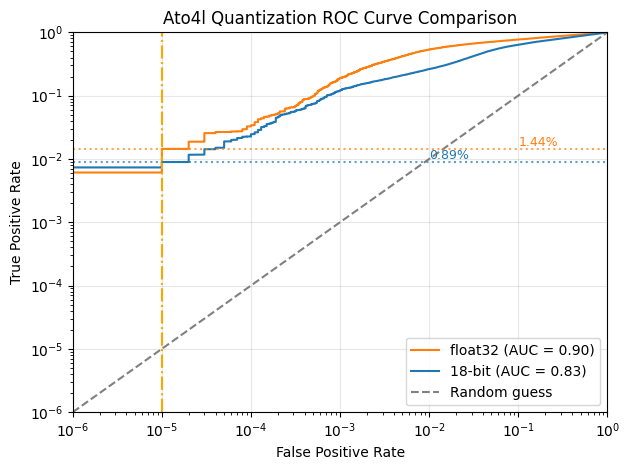

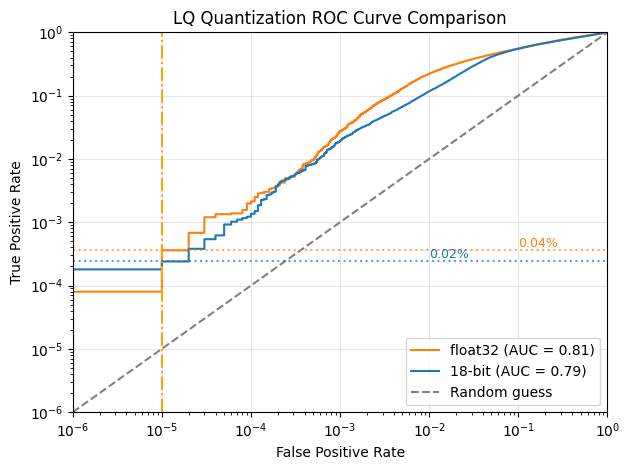

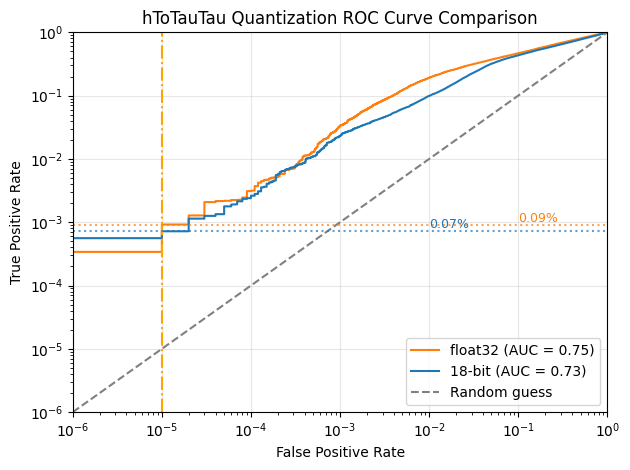

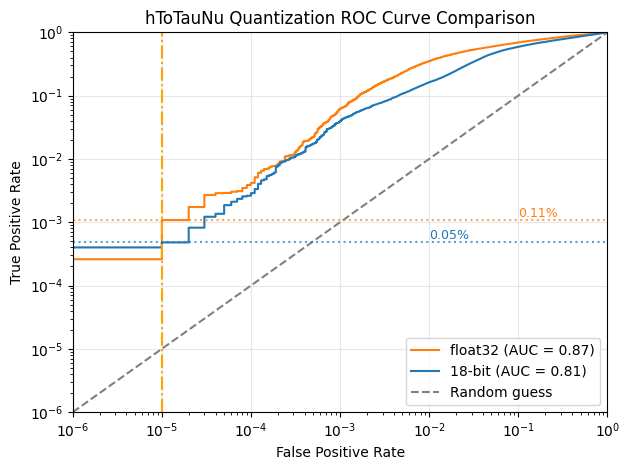

In [57]:
def plot_roc_curve(fpr, tpr, auc_value, label, color, savename):
    plt.plot(fpr[0], tpr[0], label=f"{label[0]} (AUC = {auc_value[0]:.2f})", color=color[0])
    plt.plot(fpr[1], tpr[1], label=f"{label[1]} (AUC = {auc_value[1]:.2f})", color=color[1])
    # plt.plot(fpr[2], tpr[2], label=f"{label[2]} (AUC = {auc_value[2]:.2f})", color=color[1], linestyle='--')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim([1e-6, 1.0])
    plt.ylim([1e-6, 1.0])
    # random guess diagonal
    plt.plot([1e-6, 1.0], [1e-6, 1.0], linestyle="--", color="gray", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title("{} Quantization ROC Curve Comparison".format(savename))
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.axvline(1e-5, color="orange", linestyle="-.")
    
    # Find the TPR at FPR closest to 1e-5
    for i in range(len(fpr)):
      idx = np.searchsorted(fpr[i], 1e-5, side="right")
      if idx >= len(tpr[i]):
        idx = -1
      tpr_val = tpr[i][idx]
      plt.axhline(y=tpr_val, xmin=0, xmax=1, color=color[i], linestyle=":", alpha=0.7)
      plt.text(1e-1**(i+1), tpr_val, f"{tpr_val*100:.2f}%", color=color[i], va="bottom", fontsize=9)

    # plt.savefig("../output/Comparison_Plots/ROCCurve_18vsfloat32_{}.png".format(savename))
    plt.show()

plot_roc_curve([fpr_Ato4l_float32, fpr_Ato4l_18bit], [tpr_Ato4l_float32, tpr_Ato4l_18bit], [auc_Ato4l_float32, auc_Ato4l_18bit], ["float32", "18-bit", "18-bit (50 target)"], [quantization_colors["float32"], quantization_colors["18-bit"], quantization_colors["18-bit"]], "Ato4l")
plot_roc_curve([fpr_LQ_float32, fpr_LQ_18bit], [tpr_LQ_float32, tpr_LQ_18bit], [auc_LQ_float32, auc_LQ_18bit], ["float32", "18-bit", "18-bit (50 target)"], [quantization_colors["float32"], quantization_colors["18-bit"], quantization_colors["18-bit"]], "LQ")
plot_roc_curve([fpr_hToTauTau_float32, fpr_hToTauTau_18bit], [tpr_hToTauTau_float32, tpr_hToTauTau_18bit], [auc_hToTauTau_float32, auc_hToTauTau_18bit], ["float32", "18-bit", "18-bit (50 target)"], [quantization_colors["float32"], quantization_colors["18-bit"], quantization_colors["18-bit"]], "hToTauTau")
plot_roc_curve([fpr_hToTauNu_float32, fpr_hToTauNu_18bit], [tpr_hToTauNu_float32, tpr_hToTauNu_18bit], [auc_hToTauNu_float32, auc_hToTauNu_18bit], ["float32", "18-bit", "18-bit (50 target)"], [quantization_colors["float32"], quantization_colors["18-bit"], quantization_colors["18-bit"]], "hToTauNu")